In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
len(words)

32033

In [8]:
min( len(w) for w in words) # shortest word

2

In [9]:
max( len(w) for w in words) # longest word

15

In [27]:
# bigram : lets worry about just 2 chars
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [33]:
k = sorted(b.items(), key = lambda kv: -kv[1])
print(k[:10])

[(('n', '<E>'), 6763), (('a', '<E>'), 6640), (('a', 'n'), 5438), (('<S>', 'a'), 4410), (('e', '<E>'), 3983), (('a', 'r'), 3264), (('e', 'l'), 3248), (('r', 'i'), 3033), (('n', 'a'), 2977), (('<S>', 'k'), 2963)]


In [34]:
import torch

In [40]:
a = torch.zeros((3,5))

In [41]:
a

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [42]:
a.dtype

torch.float32

In [43]:
a = torch.zeros((3,5), dtype = torch.int32)

In [44]:
a.dtype

torch.int32

In [45]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [78]:
# our case we have 26 letters and <S> and <E> so total 28.

N = torch.zeros((28,28), dtype = torch.int32)

In [79]:
chars = sorted(set(''.join(words)))

stoi = {s:i for i,s in enumerate(chars)}
itos = {i:s for i,s in enumerate(chars)}


stoi['<S>'] = 26
stoi['<E>'] = 27
itos[26] = '<S>'
itos[27] = '<E>'

stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [80]:

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1]][stoi[ch2]] += 1


In [72]:
import matplotlib.pyplot as plt
%matplotlib inline


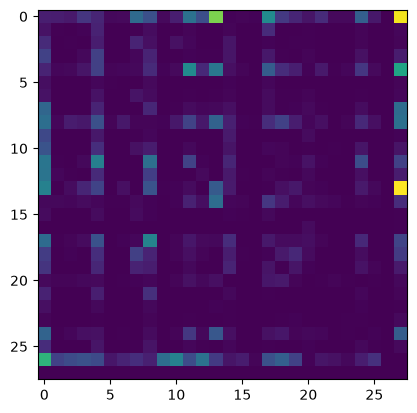

In [73]:
plt.imshow(N)

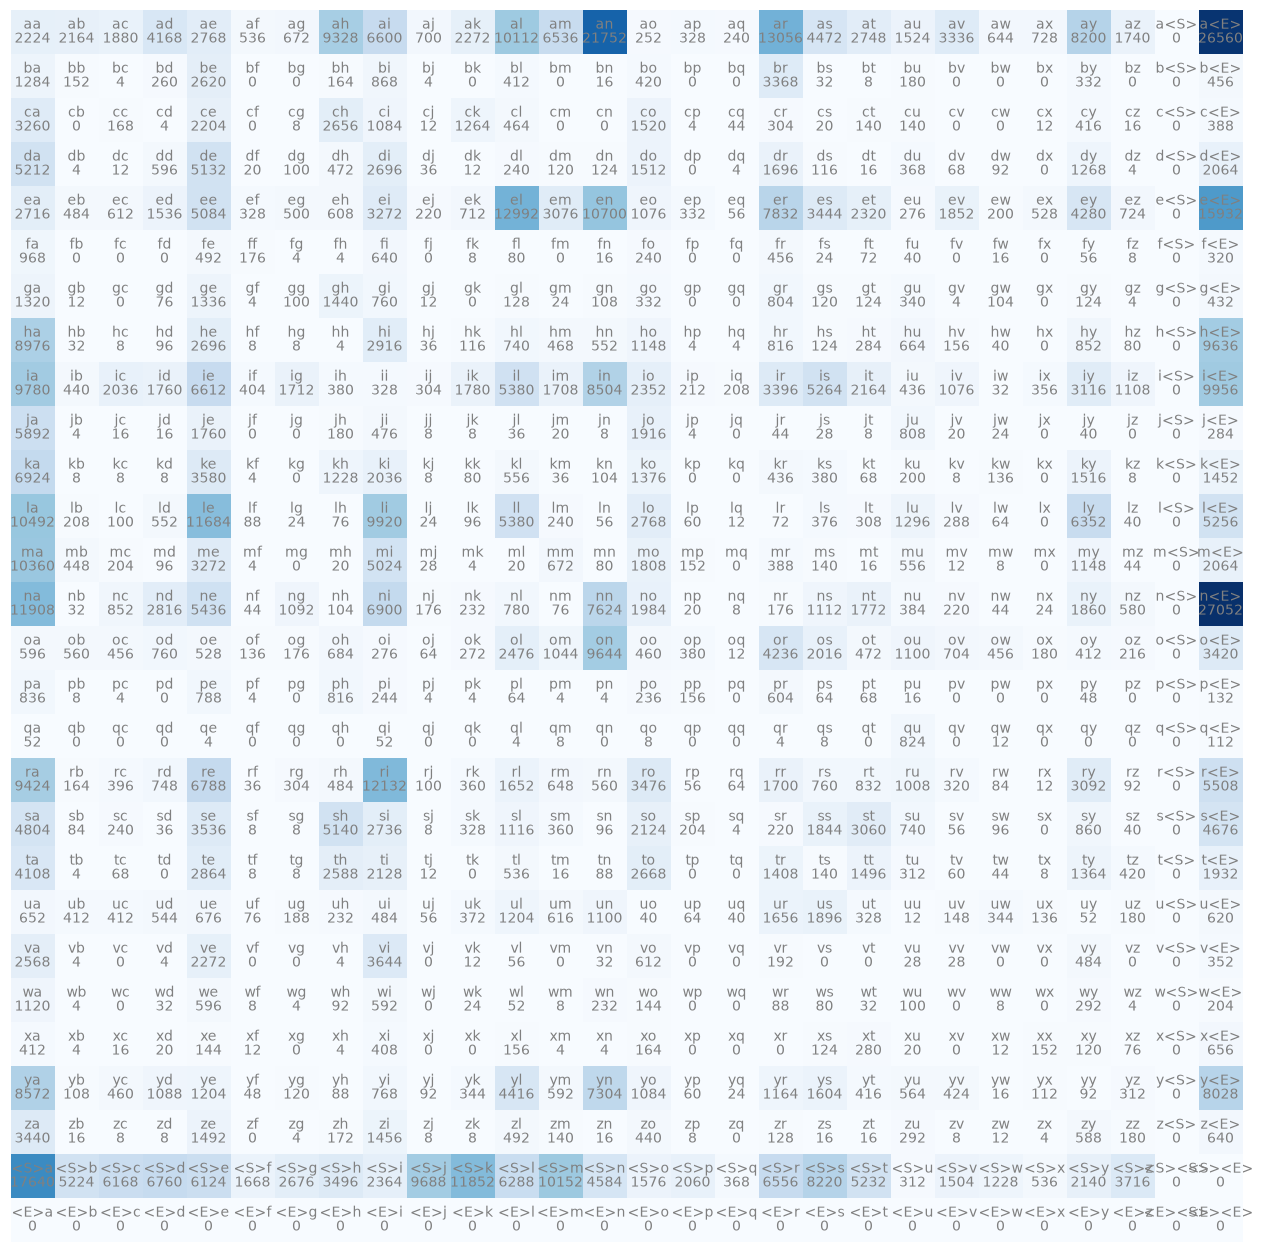

In [75]:

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [144]:
# our case we have 26 letters and for <S> and <E> lets use `.` so total 27.

N = torch.zeros((27,27), dtype = torch.int32)

chars = sorted(set(''.join(words)))

stoi = {s:i+1 for i,s in enumerate(chars)}

stoi['.'] = 0

itos = {idx: ch for ch, idx in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [145]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1]][stoi[ch2]] += 1


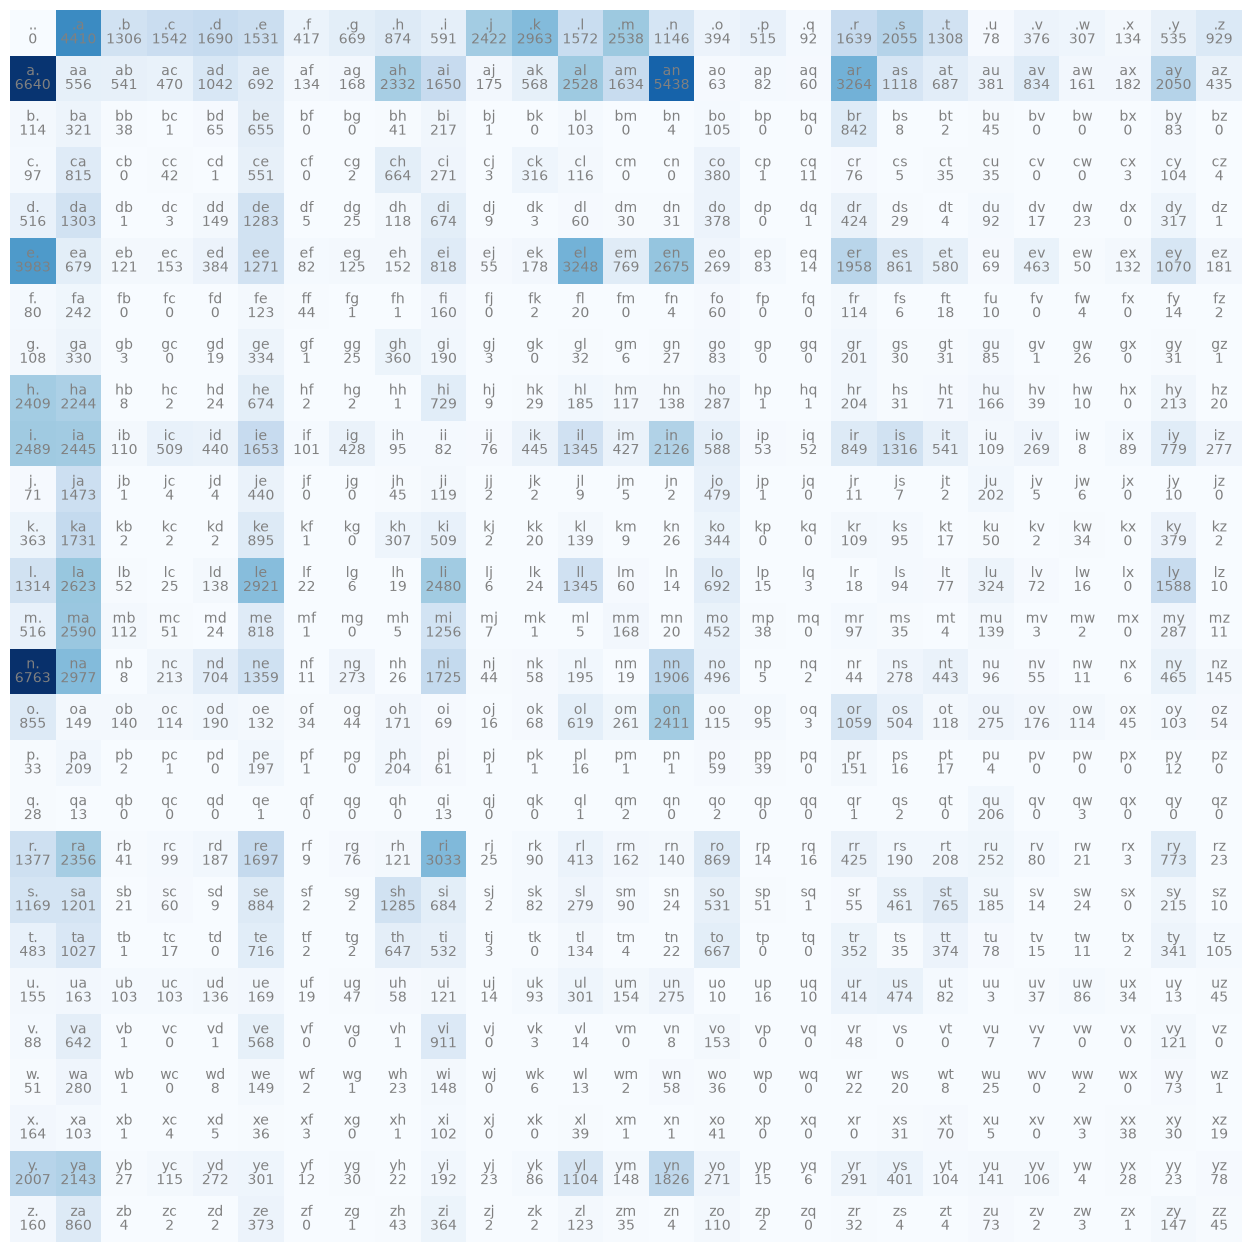

In [146]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [147]:
N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [148]:
N[0, :].shape

torch.Size([27])

In [149]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [182]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [183]:
sum(p)

tensor(1.)

In [186]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(4, generator=g)
p = p / p.sum()
p # ---- this is the distribution


tensor([0.4007, 0.2004, 0.0597, 0.3393])

In [187]:
torch.multinomial(p, num_samples=10, replacement=True, generator=g)


tensor([3, 0, 0, 3, 3, 0, 2, 3, 2, 1])

In [189]:
# now lets do for our code


p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [190]:
g = torch.Generator().manual_seed(2147483647)
index = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

itos[index]

'c'

In [191]:
g = torch.Generator().manual_seed(2147483647)

ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum() # normalize 
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    print(itos[ix])
    if ix == 0: break;
    


c
e
x
z
e
.


In [173]:
p.shape

torch.Size([27])

In [192]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum() # normal distribution

        # p = tensor.ones(27) / 27.0 ---> uniform distribution
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: break;
        
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [219]:
  # p = N[ix].float()
  # p = p / p.sum() # insted of doing this every time we can calc probability prior and store them
  # just P.sum give the sum of the whole 

# to make sure p is non zero we are using +1; ie (N+1).float()

P = (N+1).float()
P /= P.sum(1, keepdim = True) # understand this

In [220]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # p = N[ix].float()
        # p = p / p.sum() # normalize distribution

        p = P[ix]

        # p = tensor.ones(27) / 27.0 ---> uniform distribution
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: break;
        
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [221]:
# loss fn


for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1][ix2] += 1
        prob = P[ix1, ix2]
        print(f'{ch1}{ch2}: {prob: .4f}')

.e:  0.0479
em:  0.0378
mm:  0.0257
ma:  0.3893
a.:  0.1961
.o:  0.0124
ol:  0.0782
li:  0.1777
iv:  0.0153
vi:  0.3527
ia:  0.1381
a.:  0.1961
.a:  0.1377
av:  0.0247
va:  0.2489
a.:  0.1961


In [222]:
# loss fn

# maximum likelyhood estimation 
# likelyhood is the product of all the probabilities
# since this probabilities are floating points btw 0,1 if we do product its harder to working with floatng points as we take the log of probabilities ie log likelyhood

# log(a*b*c) = log a + log b + log c

log_likelyhood = 0.0 
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1][ix2] += 1
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelyhood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')

print(f'{log_likelyhood: .4f}')

-559933.5000


In [223]:
# since log_likelyhood is from -100 to 0, we take -ve log_likelyhood 

nll = -1 * log_likelyhood
print(f'{nll= }')

# if we avg out this nll that is our over all loss fn --> average negative log likelihood

print(f'{nll/n= }')


# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)


nll= tensor(559933.5000)
nll/n= tensor(2.4543)


In [228]:
n = 0
log_likelyhood =0
for w in ["dileepq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1][ix2] += 1
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelyhood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')

print(f'{log_likelyhood: .4f}')
nll = -1 * log_likelyhood
print(f'{nll= }')
print(f'{nll/n}')


.d:  0.0528 -2.9416
di:  0.1227 -2.0983
il:  0.0760 -2.5769
le:  0.2092 -1.5647
ee:  0.0623 -2.7762
ep:  0.0042 -5.4827
pq:  0.0005 -7.6411
q.:  0.0998 -2.3043
-27.3858
nll= tensor(27.3858)
3.423220634460449


In [249]:
# now lets try alternative approach where we use neural network framework
# 
# step 1: create a training set of bigrams(x, y)

xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [250]:
xs

tensor([ 0,  5, 13, 13,  1])

In [251]:
ys

tensor([ 5, 13, 13,  1,  0])

In [252]:
# giving the above vector as a nn input doesn't makes sense because here numbers represent a character so 2 doesnt mean 1 + 1, thats why we use one_hot

import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27)

xenc

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

In [253]:
xenc.shape

torch.Size([5, 27])

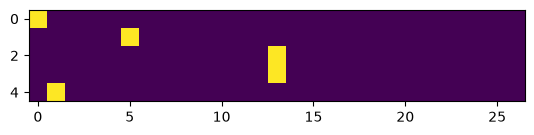

In [254]:
plt.imshow(xenc)

In [255]:
xenc.dtype

torch.int64

In [256]:
xenc = F.one_hot(xs, num_classes = 27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [257]:
W = torch.randn((27,1))
W

tensor([[ 1.7454e-01],
        [-9.5529e-01],
        [ 1.1613e+00],
        [ 3.3122e-01],
        [-1.5474e+00],
        [-1.0221e+00],
        [ 1.0871e+00],
        [-2.1270e-01],
        [-2.2751e-01],
        [ 2.8634e-01],
        [ 4.6351e-02],
        [-1.7798e+00],
        [-1.1178e+00],
        [-1.8799e-01],
        [ 3.6633e-01],
        [-3.8087e-01],
        [-5.2280e-01],
        [-4.8482e-01],
        [-4.1514e-01],
        [-6.8679e-02],
        [-2.6790e-01],
        [-2.0044e+00],
        [ 1.3837e+00],
        [-1.0173e+00],
        [ 7.0277e-01],
        [-2.1064e+00],
        [-2.1986e-04]])

In [259]:
# '@' is a matrix multiplication symbol in pytorch

# (5, 27) @ (27, 1) = (5, 1)

W = torch.randn((27,1))
xenc @ W

tensor([[ 0.1745],
        [-1.0221],
        [-0.1880],
        [-0.1880],
        [-0.9553]])

In [265]:
# (5, 27) @ (27, 27) = (5, 27)

W = torch.randn((27,27))
logits = xenc @ W # log counts
logits

tensor([[-1.5014, -0.2639, -0.9852,  0.4234,  0.0845,  0.3895, -1.2171, -0.3494,
         -0.9157, -0.5661,  0.0780,  1.3389,  0.1633,  1.5847, -1.1452,  0.6212,
         -0.4787, -0.1592, -1.0322,  0.7869,  0.2153, -0.7345, -0.5322,  1.2104,
         -0.1527,  1.5262,  0.5558],
        [ 0.6372,  0.4554,  0.5770,  0.0615,  0.3268, -0.2580, -0.5620,  0.1401,
          0.3185, -0.1815, -0.6010, -0.8840,  0.5522, -0.4605,  0.7344, -0.3581,
          0.8145, -0.0159, -0.3437, -1.8649,  0.1838, -0.3730, -0.3769, -0.5357,
         -0.6255,  0.9167, -0.4306],
        [ 0.0979, -0.4405, -0.6358, -1.1786, -0.7237, -0.6453,  0.3389,  0.1971,
          1.3839, -0.9610,  0.3925, -0.2746,  0.1675, -1.8515, -0.9569, -0.6879,
         -0.4315,  0.9833,  0.9001,  0.8146,  0.5888,  0.4918, -1.5533,  0.1007,
          0.0064,  2.3416,  0.3071],
        [ 0.0979, -0.4405, -0.6358, -1.1786, -0.7237, -0.6453,  0.3389,  0.1971,
          1.3839, -0.9610,  0.3925, -0.2746,  0.1675, -1.8515, -0.9569, -0.6879

In [267]:
# we need counts but nn outputs floating point numbers and they can also be negitive, so we interpret nn output as log counts. 
# to get count we take log counts and exponentiate them (e^x will always give output as +ve)
counts = logits.exp()
counts

tensor([[ 0.2228,  0.7680,  0.3734,  1.5271,  1.0881,  1.4762,  0.2961,  0.7051,
          0.4002,  0.5678,  1.0812,  3.8147,  1.1774,  4.8780,  0.3182,  1.8612,
          0.6196,  0.8528,  0.3562,  2.1967,  1.2402,  0.4797,  0.5873,  3.3549,
          0.8584,  4.6004,  1.7433],
        [ 1.8912,  1.5769,  1.7807,  1.0634,  1.3866,  0.7726,  0.5701,  1.1504,
          1.3751,  0.8340,  0.5483,  0.4131,  1.7370,  0.6310,  2.0843,  0.6990,
          2.2580,  0.9842,  0.7091,  0.1549,  1.2017,  0.6886,  0.6860,  0.5852,
          0.5350,  2.5011,  0.6501],
        [ 1.1028,  0.6437,  0.5295,  0.3077,  0.4850,  0.5245,  1.4033,  1.2179,
          3.9904,  0.3825,  1.4807,  0.7599,  1.1823,  0.1570,  0.3841,  0.5026,
          0.6495,  2.6732,  2.4598,  2.2583,  1.8019,  1.6353,  0.2116,  1.1059,
          1.0064, 10.3977,  1.3595],
        [ 1.1028,  0.6437,  0.5295,  0.3077,  0.4850,  0.5245,  1.4033,  1.2179,
          3.9904,  0.3825,  1.4807,  0.7599,  1.1823,  0.1570,  0.3841,  0.5026

In [272]:
probs = counts / counts.sum(1, keepdims=True)

In [273]:
probs

tensor([[0.0060, 0.0205, 0.0100, 0.0408, 0.0291, 0.0394, 0.0079, 0.0188, 0.0107,
         0.0152, 0.0289, 0.1019, 0.0314, 0.1303, 0.0085, 0.0497, 0.0165, 0.0228,
         0.0095, 0.0587, 0.0331, 0.0128, 0.0157, 0.0896, 0.0229, 0.1229, 0.0466],
        [0.0642, 0.0535, 0.0604, 0.0361, 0.0471, 0.0262, 0.0193, 0.0390, 0.0467,
         0.0283, 0.0186, 0.0140, 0.0589, 0.0214, 0.0707, 0.0237, 0.0766, 0.0334,
         0.0241, 0.0053, 0.0408, 0.0234, 0.0233, 0.0199, 0.0182, 0.0849, 0.0221],
        [0.0272, 0.0158, 0.0130, 0.0076, 0.0119, 0.0129, 0.0346, 0.0300, 0.0983,
         0.0094, 0.0365, 0.0187, 0.0291, 0.0039, 0.0095, 0.0124, 0.0160, 0.0658,
         0.0606, 0.0556, 0.0444, 0.0403, 0.0052, 0.0272, 0.0248, 0.2560, 0.0335],
        [0.0272, 0.0158, 0.0130, 0.0076, 0.0119, 0.0129, 0.0346, 0.0300, 0.0983,
         0.0094, 0.0365, 0.0187, 0.0291, 0.0039, 0.0095, 0.0124, 0.0160, 0.0658,
         0.0606, 0.0556, 0.0444, 0.0403, 0.0052, 0.0272, 0.0248, 0.2560, 0.0335],
        [0.0202, 0.0190,

In [274]:
probs[0].sum()

tensor(1.)

In [282]:
# ok lets write out our whole forward pass

W = torch.randn((27,27))

xenc = F.one_hot(xs, num_classes = 27).float() # input to the NN: one hot encoding

logits = xenc @ W # predict log counts

counts = logits.exp() # counts, equivalent to N

probs = counts / counts.sum(1, keepdims=True) # prob for the next character

# btw the last 2 lines here are togather called softmax

In [283]:
probs.shape

torch.Size([5, 27])

In [284]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0284, 0.0061, 0.0345, 0.0099, 0.0754, 0.0236, 0.0260, 0.1336, 0.0557,
        0.0349, 0.0473, 0.0078, 0.0479, 0.0259, 0.0119, 0.0479, 0.0105, 0.0229,
        0.0570, 0.0303, 0.0222, 0.0088, 0.1251, 0.0356, 0.0159, 0.0170, 0.0380])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.023585522547364235
log likelihood: -3.747122287750244
negative log likelihood: 3.747122287750244
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0326, 0.0078, 0.0335, 0.0656, 0.0143, 0.0435, 0.0123, 0.0756, 0.1185,
        0.0188, 0.0186, 0.0602, 0.0247, 0.0171, 0.0477, 0.0352, 0.0035, 0.0603,
        0.1200, 0.0253, 0.0238, 0.0277, 0.0122, 0.0089, 0.0327, 0.0330, 0.0264])
label (actual next character): 13
probability assigned by the net to the the correct character: 0

In [366]:
# now lets try alternative approach where we use neural network framework
# 
# step 1: create a training set of bigrams(x, y)

xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [367]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [368]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [369]:
W = torch.randn((27,27), requires_grad = True)


In [370]:
# optimization

In [384]:

# forward pass
xenc = F.one_hot(xs, num_classes = 27).float() # input to the NN: one hot encoding

logits = xenc @ W # predict log counts

counts = logits.exp() # counts, equivalent to N

probs = counts / counts.sum(1, keepdims=True) # prob for the next character

In [385]:
# we need ([index, ys]) probs[0,5] probs[0,13] probs[0,13] probs[0,1] probs[0,0]
num = xs.nelement()
probs[torch.arange(num), ys]

tensor([0.1320, 0.0159, 0.0090,  ..., 0.0432, 0.0582, 0.0049],
       grad_fn=<IndexBackward0>)

In [386]:
loss = -probs[torch.arange(num), ys].log().mean() # negitive avg log likelehood
loss

tensor(3.7103, grad_fn=<NegBackward0>)

In [387]:
# backward pass
W.grad = None # set to zero
loss.backward()


In [388]:
# update
W.data += -0.1 * W.grad

In [414]:
# every thing in one place
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

2.4815850257873535
2.4815757274627686
2.4815661907196045
2.4815571308135986
2.481548309326172
2.481539011001587
2.481529951095581
2.4815211296081543
2.4815120697021484
2.48150372505188
2.481494903564453
2.4814863204956055
2.481477975845337
2.4814693927764893
2.4814612865448
2.4814529418945312
2.481444835662842
2.4814372062683105
2.4814293384552
2.4814212322235107
2.4814133644104004
2.481405735015869
2.481398105621338
2.4813904762268066
2.4813828468322754
2.4813756942749023
2.48136830329895
2.481360912322998
2.481353521347046
2.481346368789673
2.4813392162323
2.481332302093506
2.481325626373291
2.481318235397339
2.481311798095703
2.4813051223754883
2.4812982082366943
2.4812917709350586
2.4812850952148438
2.481278419494629
2.4812722206115723
2.4812655448913574
2.481259346008301
2.481252908706665
2.4812469482421875
2.481240749359131
2.4812347888946533
2.4812285900115967
2.48122239112854
2.4812164306640625
2.481210708618164
2.4812049865722656
2.481199264526367
2.481193780899048
2.481187820